In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
# Load all Data from Folder Data

# get all file names in the folder
files = os.listdir("Data")

# load all files into a dictionary
data = {}
for file_name in files:
    # read data
    df = pd.read_csv("Data/" + file_name, sep=';', skiprows=1)

    # read metadata
    with open("Data/" + file_name, encoding="utf-8") as file:
        metadata_line = file.readline().strip()
        metadata_parts = metadata_line.split(",")[1:]  # "meta," entfernen
        metadata = {kv.split("=")[0]: kv.split("=")[1] for kv in metadata_parts}

    data[file_name] = {"df": df, "metadata": metadata}

# Sort data by development time (ascending)
data = dict(sorted(data.items(), key=lambda x: int(x[1]["metadata"]["time"])))

In [28]:
def calculate_parameters(df):
    # Calculate base fog (minimum density) for each dataset
    base_fog = df["Density"].min()

    # Define Point A as 0.1D above base fog
    point_A_density = round(base_fog + 0.1, 2)

    # Find the corresponding LogE values for Point A
    point_A_LogE = np.interp(point_A_density, df["Density"], df["LogE"])
    point_A = { "LogE": round(point_A_LogE, 3), "Density": round(point_A_density, 3) }

    # Define LogE value for Aim Point B (1.30 units above base LogE)
    logE_B = point_A["LogE"] + 1.30

    # Calculate the actual density for Point B (1.30 units above Point A)
    actual_B_density = np.interp(logE_B, df["LogE"], df["Density"])
    actual_B = { "LogE": round(logE_B, 3), "Density": round(actual_B_density, 3) }

    # Calculate the expected density for Point B (0.80 ± 0.05 above Point A)
    expected_density_B = point_A["Density"] + 0.80

    # Calculate the LogE value for the expected density points
    expected_B_LogE = np.interp(expected_density_B, df["Density"], df["LogE"])
    expected_B = { "LogE": round(expected_B_LogE, 3), "Density": expected_density_B }

    # Check if B is within the expected range
    B_in_range = (actual_B["Density"] >= expected_density_B - 0.05) and (actual_B["Density"] <= expected_density_B + 0.05)

    # If B is in range, calculate ISO
    ISO = 800 / (10**point_A["LogE"])

    # Calculate gamma from Point A to Point B
    gamma = (actual_B["Density"] - point_A["Density"]) / (actual_B["LogE"] - point_A["LogE"])

    return {
        "base_fog": base_fog,
        "point_A": point_A,
        "actual_B": actual_B,
        "expected_B": expected_B,
        "B_in_range": B_in_range,
        "ISO": ISO,
        "gamma": gamma
    }

In [29]:
def plot_hd_curve(df, parameters, metadata):
    base_fog = parameters['base_fog']
    point_A = parameters['point_A']
    actual_B = parameters['actual_B']
    expected_B = parameters['expected_B']
    B_in_range = parameters['B_in_range']
    ISO = parameters['ISO']
    gamma = parameters['gamma']

    plt.figure(figsize=(10, 6))

    # Define major ticks 0.3 for x-axis and 0.2 for y-axis
    plt.xticks(np.arange(0, 4, 0.3))
    plt.yticks(np.arange(0, 3, 0.2))
    plt.ylim(0, 3)

    # Define minor ticks 0.1 for x-axis and 0.1 for y-axis
    plt.minorticks_on()
    plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(0.1))
    plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(0.1))

    # Set grid to be displayed on minor ticks
    plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')

    # Plot the H and D curves
    plt.plot(df["LogE"], df["Density"], marker='.', linestyle='-', label="D76", color='darkslategrey')

    # Mark Points A and B on the plot
    plt.plot(point_A["LogE"], point_A["Density"], marker='|', linestyle='', color='indigo', label="Point A", zorder=5, markersize=20, markeredgewidth=2)
    plt.text(point_A["LogE"] + .06, point_A["Density"] - .1, f"A: {point_A['LogE']}LogE, {point_A['Density']}D", color='black', bbox=dict(facecolor='white', alpha=1))

    plt.plot(actual_B["LogE"], actual_B["Density"], marker='|', linestyle='', color='indigo', label="Point B", zorder=5, markersize=20, markeredgewidth=2)
    plt.text(actual_B["LogE"] + .06, actual_B["Density"] - 0.1, f"B: {actual_B['LogE']}LogE, {actual_B['Density']}D", color='black', bbox=dict(facecolor='white', alpha=1))

    # draw gamma line
    plt.plot([point_A["LogE"], actual_B["LogE"]], [point_A["Density"], actual_B["Density"]], linestyle='--', color='gray', label="Gamma", zorder=0)
    plt.text(df["LogE"].max() - 0.5, base_fog - 0.1, f"Gamma: {gamma:.3f}", color='black', bbox=dict(facecolor='white', alpha=1))

    # Draw horizontal line to expected Point B density over the full x-axis range
    plt.hlines(expected_B["Density"], df["LogE"].min(), df["LogE"].max(), colors='green', linestyles='dashed', label="Expected Point B")
    # +/- 0.05 density range over the full x-axis range
    plt.hlines(expected_B["Density"] + 0.05, df["LogE"].min(), df["LogE"].max(), colors='green', linestyles='dotted')
    plt.hlines(expected_B["Density"] - 0.05, df["LogE"].min(), df["LogE"].max(), colors='green', linestyles='dotted')

    # Base fog line
    plt.hlines(base_fog, df["LogE"].min(), df["LogE"].max(), colors='slategray', linestyles='dotted', label="Base Fog")
    plt.text(df["LogE"].max() - 0.5, base_fog + 0.1, f"Base Fog: {base_fog:.3f}D", color='black', bbox=dict(facecolor='white', alpha=1))

    # Write the ISO value on the plot
    if B_in_range:
        plt.text(df["LogE"].max() - 0.5, base_fog + 0.3, f"ISO: {ISO:.2f}", color='black', bbox=dict(facecolor='lightgreen', alpha=1))
    else:
        plt.text(df["LogE"].max() - 0.5, base_fog + 0.3, f"ISO: {ISO:.2f}", color='black', bbox=dict(facecolor='lightcoral', alpha=1))


    # Labels and title
    plt.xlabel("Log Exposure (LogE)")
    plt.ylabel("Density")
    plt.title(f"H + D Curve for {metadata['film']} with {metadata['dev']} ({metadata['dilution']}) | {metadata['time']}min @ {metadata['temp']}°C")
    plt.legend()
    plt.grid(True)

    # Show the plot
    plt.show()

Calculating parameters for HC-110_H_5min.csv


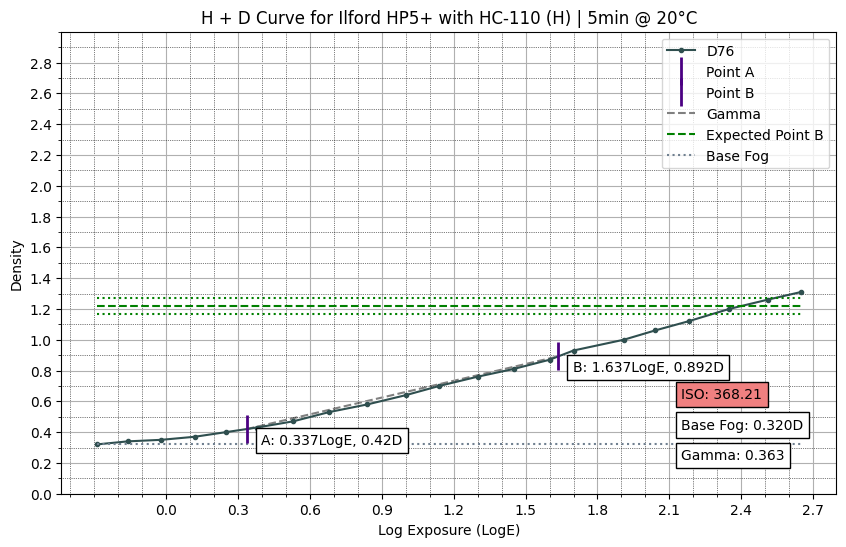

Calculating parameters for HC-110_H_10min.csv


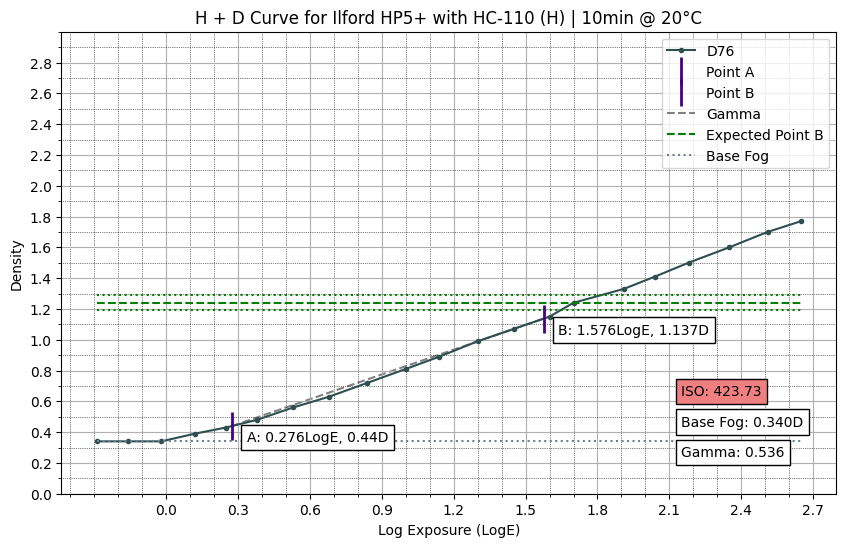

Calculating parameters for HC-110_H_20min.csv


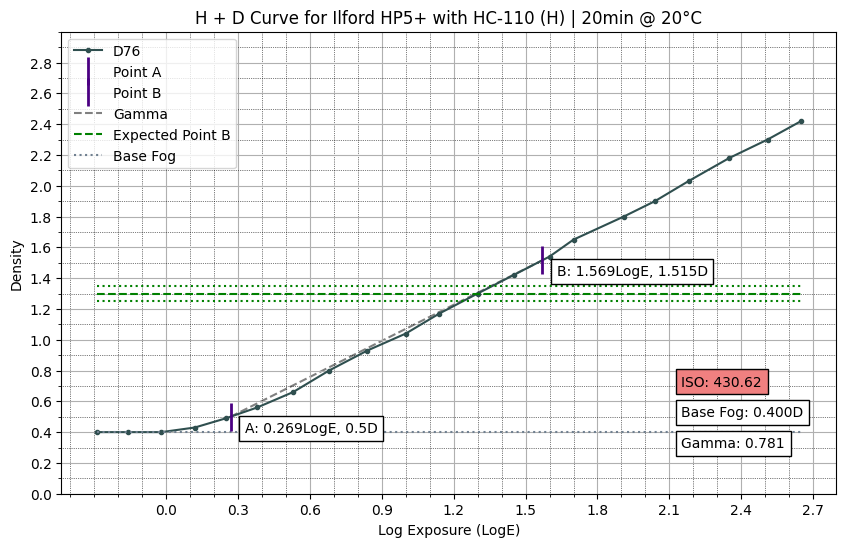

In [30]:
# Loop through all datasets and calculate parameters

# save all parameters in a dictionary
parameters = {}


# calculate all parameters for each dataset
for key in data.keys():
    print(f"Calculating parameters for {key}")
    params = calculate_parameters(data[key]["df"])
    data[key]["parameters"] = params
    plot_hd_curve(data[key]["df"], data[key]["parameters"], data[key]["metadata"])

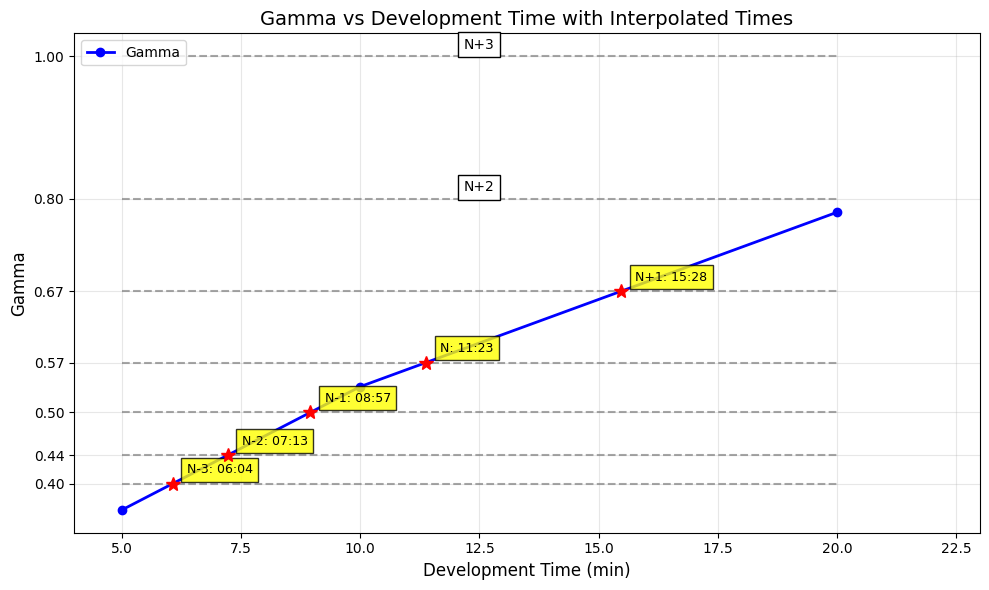

In [35]:
# Extract time, gamma, and ISO values from the data dictionary
times = [int(data[key]['metadata']['time']) for key in data.keys()]
gammas = [data[key]['parameters']['gamma'] for key in data.keys()]

# Function to convert decimal minutes to mm:ss format
def minutes_to_mmss(minutes):
    total_seconds = minutes * 60
    mins = int(total_seconds // 60)
    secs = int(total_seconds % 60)
    return f"{mins:02d}:{secs:02d}"

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(times, gammas, marker='o', linestyle='-', color='b', label='Gamma', linewidth=2, markersize=6)

# Insert horizontal lines for specified gamma values
gamma_values = [0.4, 0.44, 0.5, 0.57, 0.67, 0.80, 1.0]
labels = ['N-3', 'N-2', 'N-1', 'N', 'N+1', 'N+2', 'N+3']

# Calculate and mark intersection points
for gamma_target, label in zip(gamma_values, labels):
    plt.hlines(gamma_target, min(times), max(times), colors='gray', linestyles='dashed', alpha=0.7)
    
    # Interpolate development time for this gamma value
    if min(gammas) <= gamma_target <= max(gammas):
        # Interpolate time for this gamma value
        interpolated_time = np.interp(gamma_target, gammas, times)
        
        # Mark the intersection point
        plt.plot(interpolated_time, gamma_target, marker='*', color='red', markersize=10, zorder=5)
        
        # Convert to mm:ss format
        time_mmss = minutes_to_mmss(interpolated_time)
        
        # Add text with interpolated time in mm:ss format
        plt.text(interpolated_time + 0.3, gamma_target + 0.015, 
                f'{label}: {time_mmss}', 
                bbox=dict(facecolor='yellow', alpha=0.8, edgecolor='black'),
                fontsize=9, ha='left')
    else:
        # If gamma value is outside range, just show the label
        plt.text((min(times) + (max(times) - min(times)) / 2), gamma_target + 0.01, 
                label, bbox=dict(facecolor='white', alpha=1), ha='center')

# Set y-ticks based on gamma values
plt.yticks(gamma_values)

# Add y-axis label for gamma
plt.ylabel('Gamma', fontsize=12)
plt.xlabel('Development Time (min)', fontsize=12)
plt.title('Gamma vs Development Time with Interpolated Times', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')

# Extend x-axis slightly for better visibility of labels
plt.xlim(min(times) - 1, max(times) + 3)

plt.tight_layout()
plt.show()

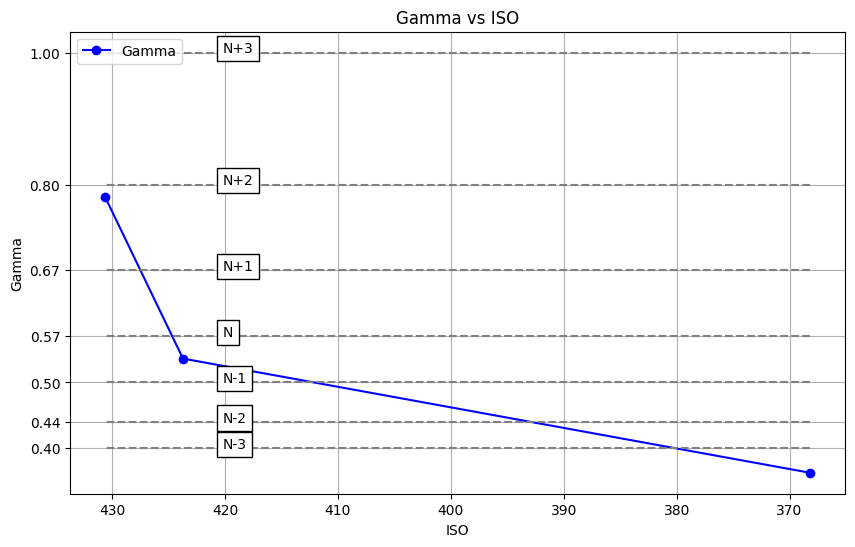

In [32]:
# Extract time, gamma, and ISO values from the data dictionary
gammas = [data[key]['parameters']['gamma'] for key in data.keys()]
isos = [data[key]['parameters']['ISO'] for key in data.keys()]

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(isos, gammas, marker='o', linestyle='-', color='b', label='Gamma')

# Insert horizontal lines for specified gamma values
gamma_values = [0.4, 0.44, 0.5, 0.57, 0.67, 0.80, 1.0]
labels = ['N-3', 'N-2', 'N-1', 'N', 'N+1', 'N+2', 'N+3']
for gamma, label in zip(gamma_values, labels):
    plt.hlines(gamma, min(isos), max(isos), colors='gray', linestyles='dashed')
    plt.text((min(isos) + (max(isos) - min(isos)) / 1.2), gamma, label, bbox=dict(facecolor='white', alpha=1))

# Set y-ticks based on gamma values
plt.yticks(gamma_values)

# Add y-axis label for gamma
plt.ylabel('Gamma')

# Invert x-axis for ISO
plt.gca().invert_xaxis()

plt.xlabel('ISO')
plt.title('Gamma vs ISO')
plt.grid(True)
plt.legend(loc='upper left')
plt.show()

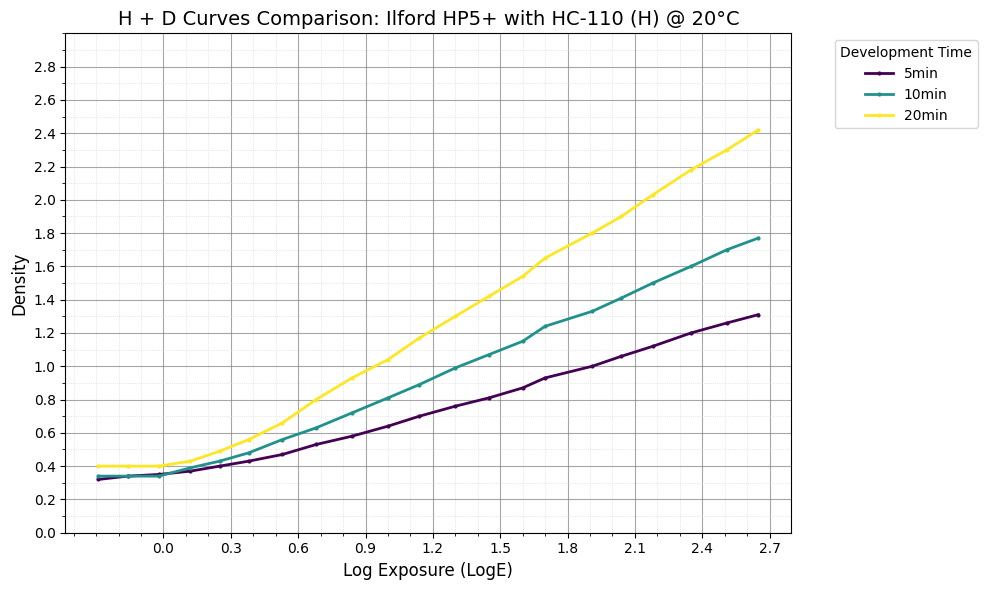

In [33]:
# Plot all H&D curves together
plt.figure(figsize=(10, 6))

# Configure the plot first
plt.xticks(np.arange(0, 4, 0.3))
plt.yticks(np.arange(0, 3, 0.2))
plt.ylim(0, 3)

# Define minor ticks
plt.minorticks_on()
plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(0.1))
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(0.1))

# Set grid to be displayed on minor ticks
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray')
plt.grid(which='major', linestyle='-', linewidth='0.8', color='gray', alpha=0.7)

# Define colors for different development times
colors = plt.cm.viridis(np.linspace(0, 1, len(data)))

# Plot each curve
for i, (key, dataset) in enumerate(data.items()):
    df = dataset["df"]
    metadata = dataset["metadata"]
    dev_time = metadata["time"]
    
    plt.plot(df["LogE"], df["Density"], 
             marker='.', linestyle='-', 
             color=colors[i], 
             label=f"{dev_time}min",
             linewidth=2, markersize=4)

# Labels and title
plt.xlabel("Log Exposure (LogE)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Get film and developer info from first dataset for title
first_dataset = list(data.values())[0]
film = first_dataset["metadata"]["film"]
dev = first_dataset["metadata"]["dev"]
dilution = first_dataset["metadata"]["dilution"]
temp = first_dataset["metadata"]["temp"]

plt.title(f"H + D Curves Comparison: {film} with {dev} ({dilution}) @ {temp}°C", fontsize=14)
plt.legend(title="Development Time", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()